# Data Preparation

In [96]:
import numpy as np
from random import randint
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler  

In [97]:
train_labels = []
train_samples = []

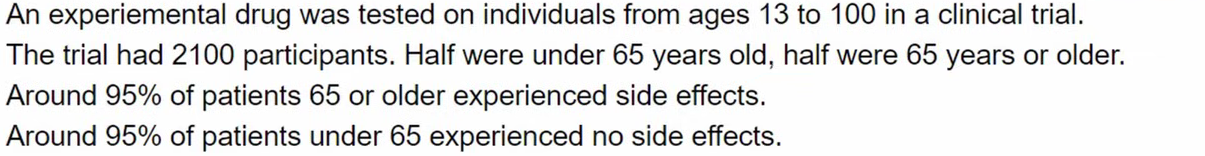

In [99]:
# creating the data by myself

for i in range(50):
    random_younger = randint(13,64)
    train_samples.append(random_younger)
    train_labels.append(1)

    random_older = randint(65,100)
    train_samples.append(random_older)
    train_labels.append(0)

for i in range(100):
    random_younger = randint(13,64)
    train_samples.append(random_younger)
    train_labels.append(0)

    random_older = randint(65,100)
    train_samples.append(random_older)
    train_labels.append(1)


In [100]:
for i in range(len(train_samples)):
    print(train_samples[i],":",train_labels[i],end = "],[")



17 : 1],[75 : 0],[32 : 1],[67 : 0],[16 : 1],[69 : 0],[30 : 1],[72 : 0],[35 : 1],[89 : 0],[32 : 1],[74 : 0],[44 : 1],[75 : 0],[22 : 1],[81 : 0],[22 : 1],[90 : 0],[28 : 1],[96 : 0],[36 : 1],[74 : 0],[40 : 1],[96 : 0],[14 : 1],[73 : 0],[16 : 1],[81 : 0],[19 : 1],[78 : 0],[58 : 1],[68 : 0],[57 : 1],[74 : 0],[49 : 1],[69 : 0],[45 : 1],[98 : 0],[56 : 1],[71 : 0],[18 : 1],[87 : 0],[53 : 1],[75 : 0],[53 : 1],[70 : 0],[58 : 1],[85 : 0],[50 : 1],[67 : 0],[30 : 1],[65 : 0],[43 : 1],[68 : 0],[52 : 1],[66 : 0],[32 : 1],[67 : 0],[58 : 1],[71 : 0],[57 : 1],[83 : 0],[27 : 1],[68 : 0],[28 : 1],[71 : 0],[14 : 1],[71 : 0],[27 : 1],[99 : 0],[22 : 1],[91 : 0],[24 : 1],[97 : 0],[15 : 1],[99 : 0],[27 : 1],[90 : 0],[21 : 1],[71 : 0],[47 : 1],[66 : 0],[46 : 1],[72 : 0],[51 : 1],[92 : 0],[24 : 1],[75 : 0],[18 : 1],[70 : 0],[48 : 1],[69 : 0],[57 : 1],[84 : 0],[47 : 1],[86 : 0],[58 : 1],[74 : 0],[43 : 1],[87 : 0],[60 : 0],[84 : 1],[24 : 0],[72 : 1],[34 : 0],[71 : 1],[63 : 0],[65 : 1],[47 : 0],[88 : 1],[37 : 0],[6

In [101]:
train_labels = np.array(train_labels)
train_samples = np.array(train_samples)
train_labels,train_samples = shuffle(train_labels,train_samples)  # to avoid the gnerated order

In [102]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_train_samples = scaler.fit_transform(train_samples.reshape(-1,1))
scaled_train_samples

array([[0.03448276],
       [0.63218391],
       [0.22988506],
       [0.16091954],
       [0.3908046 ],
       [0.12643678],
       [0.26436782],
       [0.10344828],
       [0.83908046],
       [0.74712644],
       [0.95402299],
       [0.06896552],
       [0.09195402],
       [0.62068966],
       [0.49425287],
       [0.6091954 ],
       [0.27586207],
       [0.27586207],
       [0.90804598],
       [0.57471264],
       [0.89655172],
       [0.17241379],
       [0.79310345],
       [0.81609195],
       [0.73563218],
       [0.5862069 ],
       [0.47126437],
       [0.50574713],
       [0.3908046 ],
       [0.74712644],
       [0.54022989],
       [0.82758621],
       [0.93103448],
       [0.63218391],
       [0.94252874],
       [0.22988506],
       [0.94252874],
       [0.08045977],
       [0.6091954 ],
       [0.89655172],
       [0.52873563],
       [0.40229885],
       [0.36781609],
       [0.03448276],
       [0.93103448],
       [0.93103448],
       [0.90804598],
       [0.344

# Simple tf.keras Sequential Model

In [104]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy

In [105]:
physical_devices = tf.config.experimental.list_physical_devices('GPU')
print("Num of Gpu avilable : ", len(physical_devices))
# tf.config.experimental.set_memory_growth(physical_devices[0],True)  # currently GPU is not working in my laptop

Num of Gpu avilable :  0


In [106]:
model = Sequential([
    Dense(units = 16,input_shape = (1,), activation = 'relu'),
    Dense(units = 32, activation = 'relu'),
    Dense(units = 2, activation = 'softmax')
])

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [107]:
model.summary()   

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 16)                  │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 642 (2.51 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

# Train the model

In [109]:
model.compile(optimizer = Adam(learning_rate = 0.001), loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])

In [110]:
model.fit(x = scaled_train_samples, y = train_labels, validation_split = 0.1, batch_size = 10,epochs = 40, shuffle = True, verbose =2 )

Epoch 1/40
27/27 - 1s - 55ms/step - accuracy: 0.4630 - loss: 0.6998 - val_accuracy: 0.3667 - val_loss: 0.6971
Epoch 2/40
27/27 - 0s - 4ms/step - accuracy: 0.5148 - loss: 0.6894 - val_accuracy: 0.3667 - val_loss: 0.7072
Epoch 3/40
27/27 - 0s - 4ms/step - accuracy: 0.5185 - loss: 0.6839 - val_accuracy: 0.3667 - val_loss: 0.7089
Epoch 4/40
27/27 - 0s - 4ms/step - accuracy: 0.5444 - loss: 0.6790 - val_accuracy: 0.4667 - val_loss: 0.7073
Epoch 5/40
27/27 - 0s - 4ms/step - accuracy: 0.5667 - loss: 0.6752 - val_accuracy: 0.5000 - val_loss: 0.7021
Epoch 6/40
27/27 - 0s - 4ms/step - accuracy: 0.5741 - loss: 0.6701 - val_accuracy: 0.5667 - val_loss: 0.7017
Epoch 7/40
27/27 - 0s - 4ms/step - accuracy: 0.6074 - loss: 0.6649 - val_accuracy: 0.5667 - val_loss: 0.7040
Epoch 8/40
27/27 - 0s - 4ms/step - accuracy: 0.6111 - loss: 0.6613 - val_accuracy: 0.5333 - val_loss: 0.7002
Epoch 9/40
27/27 - 0s - 4ms/step - accuracy: 0.6185 - loss: 0.6563 - val_accuracy: 0.5333 - val_loss: 0.6996
Epoch 10/40
27/27 

# Predictions from test data set

###  Pre processing pest data

In [138]:
test_labels = []
test_samples = []

for i in range(10):
    random_younger = randint(13,64)
    test_samples.append(random_younger)
    test_labels.append(1)

    random_older = randint(65,100)
    test_samples.append(random_older)
    test_labels.append(0)

for i in range(200):
    random_younger = randint(13,64)
    test_samples.append(random_younger)
    test_labels.append(0)

    random_older = randint(65,100)
    test_samples.append(random_older)
    test_labels.append(1)

In [140]:
test_labels = np.array(test_labels)
test_samples = np.array(test_samples)
test_labels, test_samples = shuffle(test_labels,test_samples)

In [150]:
scaled_test_samples = scaler.fit_transform(test_samples.reshape(-1,1))

# Predict

In [155]:
predictions = model.predict(x = scaled_test_samples, batch_size = 10, verbose = 0)

In [159]:
for i in predictions:
    print(i)

[0.6505304 0.3494695]
[0.3436139  0.65638614]
[0.6791029  0.32089713]
[0.67437696 0.32562304]
[0.6002514  0.39974856]
[0.6092372  0.39076272]
[0.4004715 0.5995285]
[0.67437696 0.32562304]
[0.5512748  0.44872528]
[0.67437696 0.32562304]
[0.25856388 0.7414361 ]
[0.5512748  0.44872528]
[0.20407908 0.79592085]
[0.67315656 0.32684338]
[0.37159836 0.62840164]
[0.19980778 0.80019224]
[0.5006786 0.4993213]
[0.29936188 0.7006381 ]
[0.45006868 0.54993135]
[0.36216325 0.63783675]
[0.6002514  0.39974856]
[0.22183993 0.77816004]
[0.23112534 0.76887465]
[0.38113245 0.6188675 ]
[0.5512748  0.44872528]
[0.19980778 0.80019224]
[0.3436139  0.65638614]
[0.42012557 0.57987446]
[0.6719339  0.32806608]
[0.51083237 0.48916763]
[0.21729839 0.7827017 ]
[0.67458016 0.32541987]
[0.45006868 0.54993135]
[0.6735637  0.32643637]
[0.679994   0.32000598]
[0.51083237 0.48916763]
[0.6781345  0.32186547]
[0.3436139  0.65638614]
[0.33451104 0.66548896]
[0.6505304 0.3494695]
[0.3907591  0.60924095]
[0.19980778 0.80019224]


In [161]:
rounded_predictions = np.argmax(predictions, axis = -1)

In [ ]:
for i in rounded_predictions:
    print(i)

In [167]:
# %matpotlib inline
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt


In [169]:
cm = confusion_matrix(y_true = test_labels, y_pred = rounded_predictions)

In [177]:
def plot_confusion_matrix(cm, classes, normalize = True, title = ' Confusion Matrix', cmap = plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes)) # Changed np.arang to np.arange
    plt.xticks(tick_marks, classes, rotation = 45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float')/ cm.sum(axis=1)[:, np.newaxis]
        print("Normalized Confusion Matrix")
    else:
        print("Confusion Matris, without normalization")

    print(cm)

    thresh = cm.max()/2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment = "center",
                color = "white" if cm[i, j] > thresh else "black") # Changed thersh to thresh

    plt.tight_layout()
    plt.ylabel("true Label")
    plt.xlabel("Predicted Label")

Normalized Confusion Matrix
[[0.91904762 0.08095238]
 [0.04761905 0.95238095]]


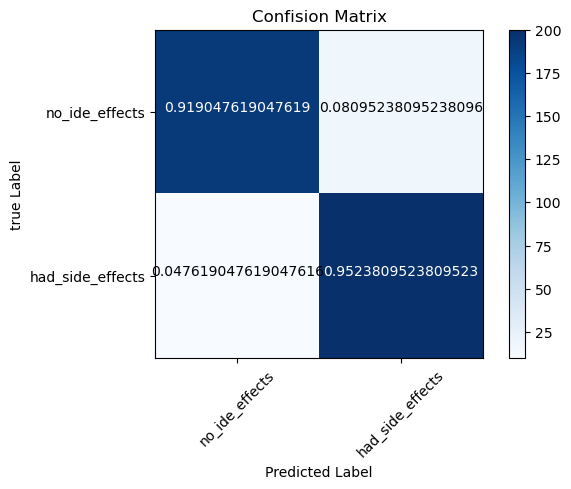

In [179]:
cm_plot_labels = ['no_ide_effects', 'had_side_effects']
plot_confusion_matrix(cm=cm, classes = cm_plot_labels, title = 'Confision Matrix')

# Save model

In [182]:
import os.path 
if os.path.isfile('models/medical_train.h5') is False:
    model.save('models/medical_train.h5')

In [186]:
from tensorflow.keras.models import load_model
new_model = load_model('models/medical_train.h5')
new_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 16)                  │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 644 (2.52 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [188]:
new_model.get_weights()

[array([[-0.23954296,  0.1626943 ,  0.02047463,  0.10026228,  0.23390545,
         -0.29714003,  0.6917443 ,  0.5042121 ,  0.610923  , -0.02965665,
          0.4530135 , -0.33393812, -0.1995939 , -0.44028786,  0.01463526,
         -0.42949402]], dtype=float32),
 array([ 0.        , -0.07442529,  0.10869916,  0.08675343, -0.08913559,
         0.        , -0.10477278, -0.1518175 , -0.12050699,  0.        ,
        -0.14806738,  0.        ,  0.        ,  0.        ,  0.121249  ,
         0.        ], dtype=float32),
 array([[ 1.56647712e-01,  2.46151239e-01, -2.39684880e-02,
          1.99885696e-01,  4.12620306e-02, -2.34265000e-01,
         -2.39995956e-01,  3.21577340e-01, -4.43448126e-02,
          1.54418975e-01,  1.80572182e-01,  3.08217406e-02,
         -1.62549093e-01,  2.19946116e-01, -3.38035852e-01,
         -1.83104783e-01, -6.84205890e-02,  1.34448946e-01,
         -3.52230817e-01, -5.35573363e-02, -2.85576940e-01,
          1.20593518e-01,  1.61957115e-01, -1.10479444e-01,
 

In [190]:
new_model.optimizer

#### model to json

In [193]:
json_str = new_model.to_json()
json_str

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential_1", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 1], "dtype": "float32", "sparse": false, "name": "input_layer_1"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Dense", "config": {"name": "dense_9", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "units": 16, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initializers", "class_name": "Zeros", "config": {}, "registered_name": null}, "kernel_regularizer": null, "bias_regularizer": null, "kernel_constra

In [197]:
from tensorflow.keras.models import model_from_json
model_archicture = model_from_json(json_str)

In [199]:
model_archicture.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 16)                  │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,928 (7.54 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,286 (5.03 KB)